# 01. Modelagem com Random Forest para Detecção de Anomalias em Logs

**Objetivo:** Este notebook tem como finalidade treinar, otimizar e avaliar um modelo de Machine Learning `Random Forest` para a tarefa de detecção de anomalias nos logs presentes no dataset "Synthetic Cybersecurity Logs for Anomaly Detection".

**Metodologia:**
1.  **Configuração do Ambiente:** Importação das bibliotecas necessárias.
2.  **Carregamento e Reparticionamento dos Dados:** Os dados pré-processados serão carregados e divididos em três conjuntos: **treino (70%)**, **validação (10%)** e **teste (20%)**. Essa separação é crucial para uma otimização de hiperparâmetros robusta e uma avaliação final imparcial.
3.  **Otimização de Hiperparâmetros:** Um processo de busca em grade (Grid Search) será conduzido para encontrar a melhor combinação de hiperparâmetros, com foco em `n_estimators`, `max_depth` e `min_samples_leaf`, além de tratar o desbalanceamento de classes.
4.  **Análise de Sensibilidade:** Gráficos serão gerados para analisar o impacto do número de árvores (`n_estimators`) na precisão (F1-Score), no custo computacional (tempo de treino) e na estabilidade (variância).
5.  **Avaliação Final:** O melhor modelo será treinado com os dados de treino e validação combinados e, finalmente, avaliado no conjunto de teste para medir seu desempenho em dados nunca antes vistos.

## 1. Configuração do Ambiente
Nesta seção, importamos todas as bibliotecas que serão utilizadas ao longo do notebook.

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

# Configurações de visualização
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Carregamento e Reparticionamento dos Dados

Os dados salvos no notebook de pré-processamento (`train_processed.npz` e `test_processed.npz`) continham uma divisão simples de 70/30 (treino/teste). Para uma otimização de hiperparâmetros confiável, precisamos de um conjunto de **validação** separado.

**Estratégia:**
1.  Carregamos e concatenamos os dados existentes para recriar o dataset completo.
2.  Realizamos uma nova divisão estratificada para garantir que a proporção de anomalias seja a mesma em todos os conjuntos:
    * **Conjunto de Teste:** 20% do total.
    * **Conjunto de Treino:** 70% do total (ou 87.5% dos 80% restantes).
    * **Conjunto de Validação:** 10% do total (ou 12.5% dos 80% restantes).

In [2]:
# Definir o caminho para os dados processados
processed_data_path = '../../data/processed/synthetic_dataset'
train_proc_path = os.path.join(processed_data_path, 'train_processed.npz')
test_proc_path = os.path.join(processed_data_path, 'test_processed.npz')

# Carregar os arrays NumPy
train_data = np.load(train_proc_path)
test_data = np.load(test_proc_path)

# Combinar os dados para recriar o dataset completo
X_full = np.vstack((train_data['X'], test_data['X']))
y_full = np.concatenate((train_data['y'], test_data['y']))

print(f"Formato do dataset completo (X): {X_full.shape}")
print(f"Formato do dataset completo (y): {y_full.shape}")
print("---")

# Primeiro, separar 20% para o conjunto de teste final
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full, test_size=0.20, random_state=42, stratify=y_full
)

# Agora, dividir os 80% restantes em treino (70%) e validação (10%)
# A proporção para o test_size aqui é 0.10 / 0.80 = 0.125
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

# Verificar as dimensões finais
print("Divisão final dos dados:")
print(f"Treino (X, y): \t{X_train.shape}, {y_train.shape} \t~{X_train.shape[0]/X_full.shape[0]:.0%}")
print(f"Validação (X, y): \t{X_val.shape}, {y_val.shape} \t~{X_val.shape[0]/X_full.shape[0]:.0%}")
print(f"Teste (X, y): \t{X_test.shape}, {y_test.shape} \t~{X_test.shape[0]/X_full.shape[0]:.0%}")

Formato do dataset completo (X): (10000, 6992)
Formato do dataset completo (y): (10000,)
---
Divisão final dos dados:
Treino (X, y): 	(7000, 6992), (7000,) 	~70%
Validação (X, y): 	(1000, 6992), (1000,) 	~10%
Teste (X, y): 	(2000, 6992), (2000,) 	~20%


In [3]:
# APLICANDO SMOTE PARA BALANCEAMENTO DO CONJUNTO DE TREINO

from imblearn.over_sampling import SMOTE
import pandas as pd # Importar pandas se ainda não estiver como pd

# -- Verificação ANTES do SMOTE --
print("--- ANTES DO SMOTE ---")
print(f"Dimensões de X_train: {X_train.shape}")
print("Distribuição das classes no conjunto de treino (y_train):")
print(pd.Series(y_train).value_counts())

# Instanciar o SMOTE
# O random_state garante que a geração de amostras seja a mesma sempre que o código rodar
smote = SMOTE(random_state=42)

# Aplicar o SMOTE *apenas* nos dados de treino
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# -- Verificação DEPOIS do SMOTE --
print("\n--- DEPOIS DO SMOTE ---")
print(f"Dimensões de X_train_resampled: {X_train_resampled.shape}")
print("Distribuição das classes no novo conjunto de treino (y_train_resampled):")
print(pd.Series(y_train_resampled).value_counts())

--- ANTES DO SMOTE ---
Dimensões de X_train: (7000, 6992)
Distribuição das classes no conjunto de treino (y_train):
0    6657
1     343
Name: count, dtype: int64

--- DEPOIS DO SMOTE ---
Dimensões de X_train_resampled: (13314, 6992)
Distribuição das classes no novo conjunto de treino (y_train_resampled):
0    6657
1    6657
Name: count, dtype: int64


## 3. Otimização de Hiperparâmetros

Vamos definir a grade de hiperparâmetros a serem testados. Para garantir a robustez estatística dos resultados, cada combinação será treinada e avaliada **5 vezes** com diferentes sementes aleatórias.

**Hiperparâmetros a serem testados:**
* `n_estimators`: Número de árvores na floresta. [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
* `max_depth`: Profundidade máxima de cada árvore para controlar o overfitting. [10, 20, None]
* `min_samples_leaf`: Número mínimo de amostras em um nó folha. [1, 5, 10]
* `class_weight`: Parâmetro para lidar com o desbalanceamento de classes. `['balanced']`

In [4]:
# Grade de hiperparâmetros a ser explorada
param_grid = {
    'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 5, 10]
}

# Número de repetições para cada combinação
n_repeats = 5

# Lista para armazenar os resultados de cada execução
results_list = []

print("Grade de parâmetros e número de repetições definidos.")

Grade de parâmetros e número de repetições definidos.


## 4. Execução do Experimento

Agora, executamos o loop de otimização. Para cada combinação de hiperparâmetros da grade, o modelo será treinado **5 vezes**. Em cada repetição, um `RandomForestClassifier` é instanciado com uma semente aleatória diferente para garantir a variabilidade.

O modelo é treinado com `(X_train, y_train)` e avaliado com `(X_val, y_val)`. Medimos o tempo de treino e as principais métricas de classificação, que são armazenadas para análise posterior.

In [5]:
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

total_runs = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_leaf']) * n_repeats
current_run = 0

print(f"Iniciando a busca em grade... Total de {total_runs} execuções.")

# Loop sobre cada combinação de hiperparâmetro
for n_est in param_grid['n_estimators']:
    for m_depth in param_grid['max_depth']:
        for m_leaf in param_grid['min_samples_leaf']:
            
            # Loop para as 5 repetições
            for i in range(n_repeats):
                current_run += 1
                print(f"Execução {current_run}/{total_runs}: n_est={n_est}, max_depth={m_depth}, min_leaf={m_leaf}, rep={i+1}")

                # Instanciar o modelo
                model = RandomForestClassifier(
                    n_estimators=n_est,
                    max_depth=m_depth,
                    min_samples_leaf=m_leaf,
                    #class_weight='balanced',  # Essencial para dados desbalanceados
                    random_state=i,           # Semente diferente a cada repetição
                    n_jobs=-1                 # Usar todos os cores de CPU
                )
                
                # Treinar o modelo e medir o tempo
                start_time = time.time()
                model.fit(X_train_resampled, y_train_resampled)
                end_time = time.time()
                train_time = end_time - start_time
                
                # Fazer previsões no conjunto de validação
                y_pred_val = model.predict(X_val)
                
                # Calcular as métricas
                f1 = f1_score(y_val, y_pred_val)
                precision = precision_score(y_val, y_pred_val)
                recall = recall_score(y_val, y_pred_val)
                specificity = calculate_specificity(y_val, y_pred_val)

                # Armazenar os resultados
                results_list.append({
                    'n_estimators': n_est,
                    'max_depth': m_depth,
                    'min_samples_leaf': m_leaf,
                    'repetition': i + 1,
                    'train_time': train_time,
                    'f1_score': f1,
                    'precision': precision,
                    'recall': recall,
                    'specificity': specificity
                })

print("\nBusca em grade concluída!")

Iniciando a busca em grade... Total de 450 execuções.
Execução 1/450: n_est=10, max_depth=10, min_leaf=1, rep=1
Execução 2/450: n_est=10, max_depth=10, min_leaf=1, rep=2
Execução 3/450: n_est=10, max_depth=10, min_leaf=1, rep=3
Execução 4/450: n_est=10, max_depth=10, min_leaf=1, rep=4
Execução 5/450: n_est=10, max_depth=10, min_leaf=1, rep=5
Execução 6/450: n_est=10, max_depth=10, min_leaf=5, rep=1
Execução 7/450: n_est=10, max_depth=10, min_leaf=5, rep=2
Execução 8/450: n_est=10, max_depth=10, min_leaf=5, rep=3
Execução 9/450: n_est=10, max_depth=10, min_leaf=5, rep=4
Execução 10/450: n_est=10, max_depth=10, min_leaf=5, rep=5
Execução 11/450: n_est=10, max_depth=10, min_leaf=10, rep=1
Execução 12/450: n_est=10, max_depth=10, min_leaf=10, rep=2
Execução 13/450: n_est=10, max_depth=10, min_leaf=10, rep=3
Execução 14/450: n_est=10, max_depth=10, min_leaf=10, rep=4
Execução 15/450: n_est=10, max_depth=10, min_leaf=10, rep=5
Execução 16/450: n_est=10, max_depth=20, min_leaf=1, rep=1
Execuç

## 5. Análise dos Resultados da Validação

Com a execução concluída, convertemos a lista de resultados em um `DataFrame` do Pandas para facilitar a análise. Agrupamos os resultados por combinação de hiperparâmetros e calculamos a média e o desvio padrão de cada métrica.

Isso nos permitirá identificar a combinação que oferece o melhor desempenho médio (focado no `F1-Score`) e que ao mesmo tempo é estável (baixo desvio padrão).

In [6]:
# Converter a lista de resultados em um DataFrame
results_df = pd.DataFrame(results_list)

# Salvar os resultados detalhados em um arquivo CSV para referência futura
results_df.to_csv('../../reports/rf_tuning_results_detailed.csv', index=False)

# Agrupar por hiperparâmetros e calcular estatísticas
agg_results_df = results_df.groupby(['n_estimators', 'max_depth', 'min_samples_leaf']).agg(
    mean_f1_score=('f1_score', 'mean'),
    std_f1_score=('f1_score', 'std'),
    mean_train_time=('train_time', 'mean')
).reset_index().sort_values(by='mean_f1_score', ascending=False)

# Identificar a melhor combinação de hiperparâmetros
best_params_row = agg_results_df.iloc[0]
best_params = best_params_row.to_dict()

print("--- Melhores Hiperparâmetros Encontrados (baseado no F1-Score médio) ---")
print(best_params_row)

# Salvar os resultados agregados
agg_results_df.to_csv('../../reports/rf_tuning_results_aggregated.csv', index=False)

--- Melhores Hiperparâmetros Encontrados (baseado no F1-Score médio) ---
n_estimators        100.000000
max_depth            20.000000
min_samples_leaf      5.000000
mean_f1_score         0.084867
std_f1_score          0.012040
mean_train_time       1.440676
Name: 58, dtype: float64


## 6. Visualização e Análise de Sensibilidade

Para entender melhor o comportamento do modelo, vamos visualizar o impacto do hiperparâmetro `n_estimators`.

1.  **Box Plot (F1-Score vs. `n_estimators`):** Mostra a sensibilidade da precisão do modelo. Podemos ver como a mediana e a dispersão do F1-Score mudam com mais árvores.
2.  **Box Plot (Tempo de Treino vs. `n_estimators`):** Mostra a sensibilidade do custo computacional. É esperado que o tempo de treino aumente linearmente com o número de árvores.
3.  **Line Plot (Variância do F1-Score vs. `n_estimators`):** Mostra a estabilidade do modelo. Idealmente, queremos uma variância baixa, indicando que o desempenho não muda drasticamente com diferentes sementes aleatórias.

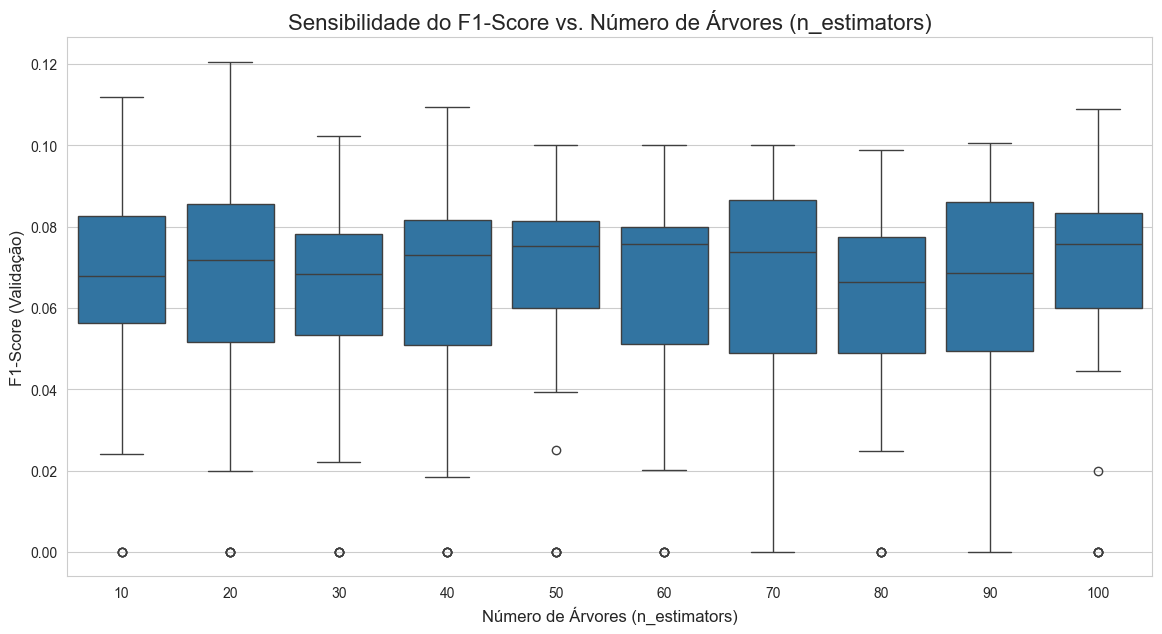

In [7]:
# Gráfico 1: Sensibilidade da Precisão (F1-Score)
plt.figure(figsize=(14, 7))
sns.boxplot(x='n_estimators', y='f1_score', data=results_df)
plt.title('Sensibilidade do F1-Score vs. Número de Árvores (n_estimators)', fontsize=16)
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('F1-Score (Validação)', fontsize=12)
plt.show()

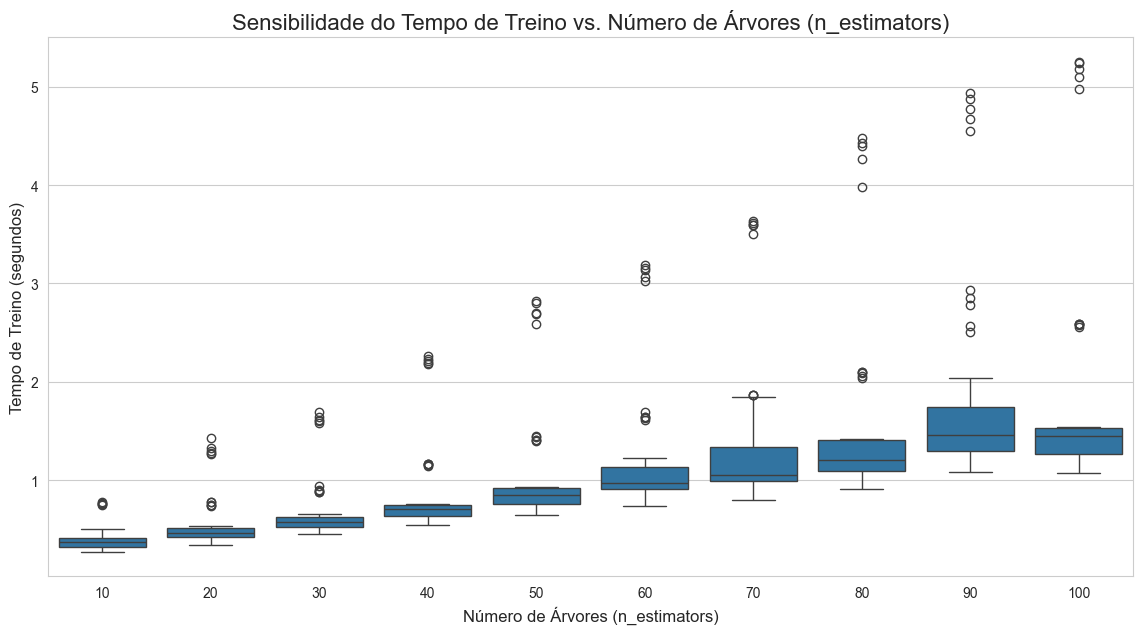

In [8]:
# Gráfico 2: Sensibilidade do Custo Computacional (Tempo de Treino)
plt.figure(figsize=(14, 7))
sns.boxplot(x='n_estimators', y='train_time', data=results_df)
plt.title('Sensibilidade do Tempo de Treino vs. Número de Árvores (n_estimators)', fontsize=16)
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('Tempo de Treino (segundos)', fontsize=12)
plt.show()

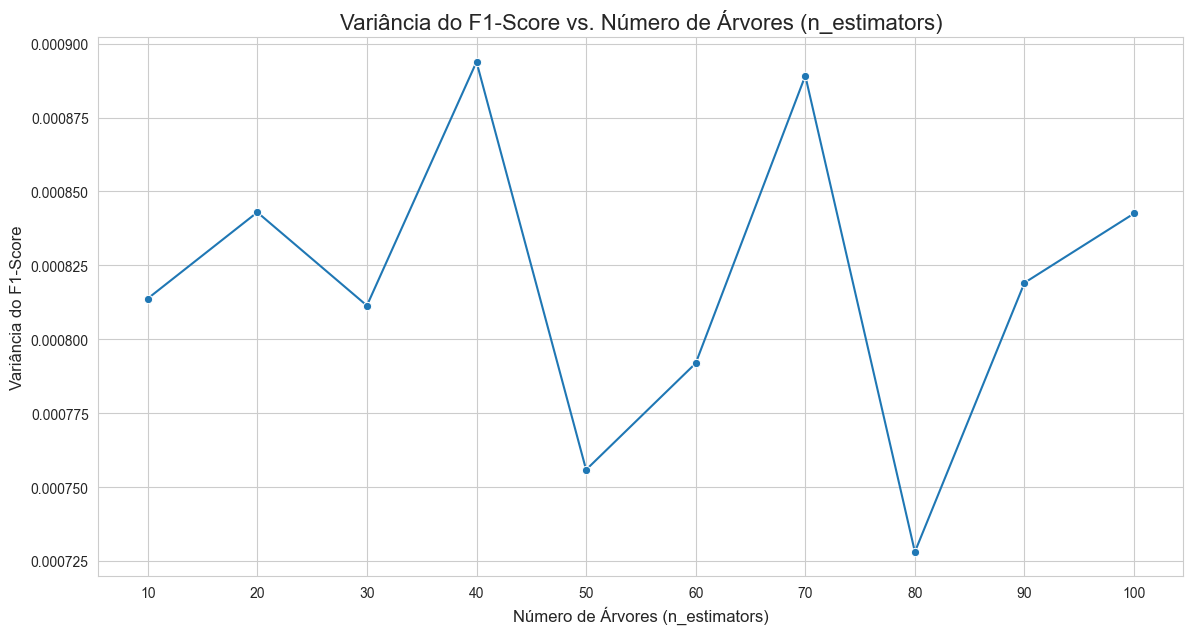

In [9]:
# Gráfico 3: Análise de Estabilidade (Variância)
variance_df = results_df.groupby('n_estimators')['f1_score'].var().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='n_estimators', y='f1_score', data=variance_df, marker='o')
plt.title('Variância do F1-Score vs. Número de Árvores (n_estimators)', fontsize=16)
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('Variância do F1-Score', fontsize=12)
plt.xticks(param_grid['n_estimators'])
plt.show()

## 7. Treino e Avaliação do Modelo Final no Conjunto de Teste

Agora que identificamos a melhor combinação de hiperparâmetros, vamos usar todo o potencial dos nossos dados de treino.

**Passos:**
1.  **Combinar os dados de treino e validação:** Criamos um conjunto de treino maior para o modelo final.
2.  **Instanciar o modelo final:** Usamos os melhores hiperparâmetros encontrados.
3.  **Treinar e Avaliar:** Treinamos no novo conjunto combinado e avaliamos, **uma única vez**, no conjunto de teste (`X_test`, `y_test`), que foi mantido intocado durante todo o processo.

Isso nos dará uma estimativa imparcial de como o modelo performará em dados do mundo real.

--- Otimização do Limiar de Decisão (Validation Set) ---
Melhor Limiar encontrado: 0.5016
F1-Score correspondente no conjunto de validação: 0.1039


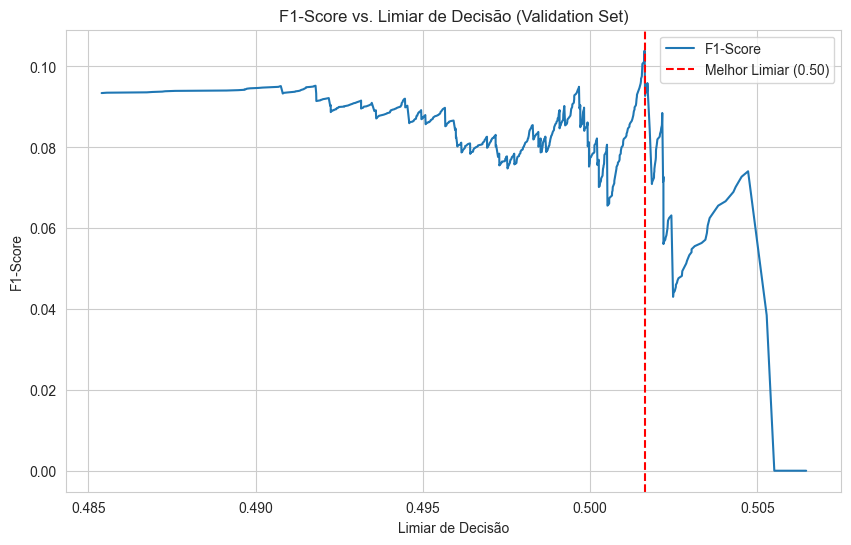

In [12]:
# Otimização do Limiar de Decisão

from sklearn.metrics import precision_recall_curve

print("--- Otimização do Limiar de Decisão (Validation Set) ---")

# Usar o melhor modelo já treinado durante o grid search
# (Aqui vamos re-treinar um modelo com os melhores hiperparâmetros para obter as probabilidades)
final_n_estimators = int(best_params['n_estimators'])
final_max_depth = best_params['max_depth']
if pd.isna(final_max_depth):
    final_max_depth = None
else:
    final_max_depth = int(final_max_depth)
final_min_samples_leaf = int(best_params['min_samples_leaf'])
best_params_dict = {
    'n_estimators': final_n_estimators,
    'max_depth': final_max_depth,
    'min_samples_leaf': final_min_samples_leaf,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

model_for_tuning = RandomForestClassifier(**best_params_dict)
model_for_tuning.fit(X_train, y_train)

# Obter as probabilidades de previsão para a classe positiva (Anomalia) no conjunto de validação
y_probs_val = model_for_tuning.predict_proba(X_val)[:, 1]

# Calcular precisão, recall e limiares
precision, recall, thresholds = precision_recall_curve(y_val, y_probs_val)

# Calcular F1-score para cada limiar
# Adicionamos um epsilon para evitar divisão por zero
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

# Encontrar o melhor limiar que maximiza o F1-score
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]

print(f"Melhor Limiar encontrado: {best_threshold:.4f}")
print(f"F1-Score correspondente no conjunto de validação: {best_f1:.4f}")

# Plotar a curva
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.xlabel("Limiar de Decisão")
plt.ylabel("F1-Score")
plt.title("F1-Score vs. Limiar de Decisão (Validation Set)")
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Melhor Limiar ({best_threshold:.2f})')
plt.legend()
plt.show()

Formato do conjunto de treino final (X, y): (8000, 6992), (8000,)
Distribuição final para treino com SMOTE: 0    7608
1    7608
Name: count, dtype: int64

Treinando o modelo final...
Treino concluído.

--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---
              precision    recall  f1-score   support

      Normal       0.95      0.87      0.91      1902
    Anomalia       0.05      0.13      0.07        98

    accuracy                           0.83      2000
   macro avg       0.50      0.50      0.49      2000
weighted avg       0.91      0.83      0.87      2000

--- Matriz de Confusão com Limiar Otimizado (Conjunto de Teste) ---


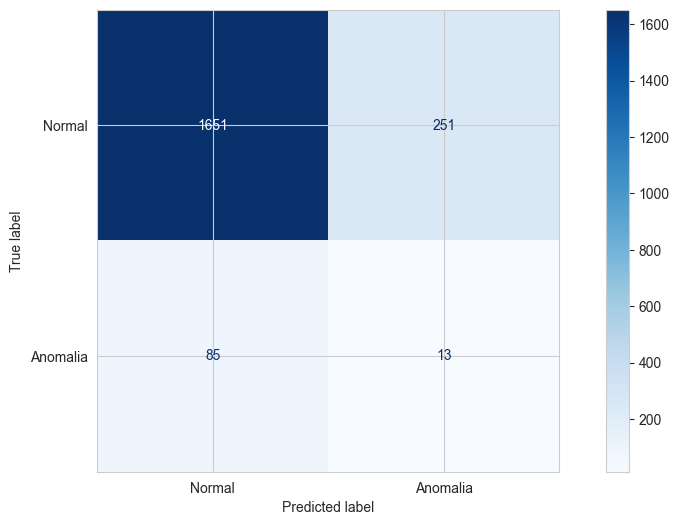

In [13]:
# Extrair os melhores parâmetros (convertendo None para o tipo correto se necessário)
final_n_estimators = int(best_params['n_estimators'])
final_max_depth = best_params['max_depth']
if pd.isna(final_max_depth):
    final_max_depth = None
else:
    final_max_depth = int(final_max_depth)
final_min_samples_leaf = int(best_params['min_samples_leaf'])


# Combinar dados de treino e validação
X_train_full = np.vstack((X_train, X_val))
y_train_full = np.concatenate((y_train, y_val))

print(f"Formato do conjunto de treino final (X, y): {X_train_full.shape}, {y_train_full.shape}")
X_train_full_resampled, y_train_full_resampled = smote.fit_resample(X_train_full, y_train_full)
print("Distribuição final para treino com SMOTE:", pd.Series(y_train_full_resampled).value_counts())

# Instanciar o modelo final com os melhores hiperparâmetros
final_model = RandomForestClassifier(
    n_estimators=final_n_estimators,
    max_depth=final_max_depth,
    min_samples_leaf=final_min_samples_leaf,
#    class_weight='balanced',
    random_state=42, # Usar uma semente fixa para reprodutibilidade
    n_jobs=-1
)

# Treinar o modelo final
print("\nTreinando o modelo final...")
final_model.fit(X_train_full_resampled, y_train_full_resampled)
print("Treino concluído.")

# Fazer previsões no conjunto de teste
y_pred_test_probs = final_model.predict_proba(X_test)[:, 1]

# Aplicar o melhor limiar encontrado
y_pred_test_tuned = (y_pred_test_probs >= best_threshold).astype(int)

# Avaliar o desempenho final
print("\n--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---")
print(classification_report(y_test, y_pred_test_tuned, target_names=['Normal', 'Anomalia']))

# Visualizar a Matriz de Confusão
print("--- Matriz de Confusão com Limiar Otimizado (Conjunto de Teste) ---")
cm_tuned = confusion_matrix(y_test, y_pred_test_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Normal', 'Anomalia'])
disp_tuned.plot(cmap=plt.cm.Blues)
plt.show()